# Gåshamna Whale Bone Osteometric Analysis

This document provides a comprehensive justification and analysis of the physical dimensions of whale bone remains at Gåshamna, analyzed within their spatial cluster contexts.

---

## 1. Osteometric Analysis (Bone Size Distribution)
Using the `size_cm` attribute, we analyze the physical dimensions of the bones within each spatial cluster defined in the DBSCAN analysis.

### A. Overall Distribution
The dataset is analyzed using a **KDE (Kernel Density Estimate)** to identify the "population signature" of whale bones on-site. A bimodal distribution (two peaks) typically indicates a split between industrial waste (small fragments) and structural materials (large intact jaws/ribs).

### B. Cluster-Specific Metrics (Boxplots)
By generating boxplots for each **Cluster ID**, we observe the "functional fingerprint" of each zone:
* **Storage/Building Zones:** Clusters with high median lengths and low variance suggest the deliberate selection of large bones (e.g., mandibles) for use as architectural supports.
* **Processing/Refuse Zones:** Clusters dominated by smaller bone sizes or highly fragmented material point toward primary butchery areas or intense trampling/crushing zones.

---

## Conclusion
Distinct **Osteometric Signatures** per cluster suggest that the spatial arrangement of whale bones at Gåshamna is a direct result of specialized industrial activities during the 17th-century whaling era.

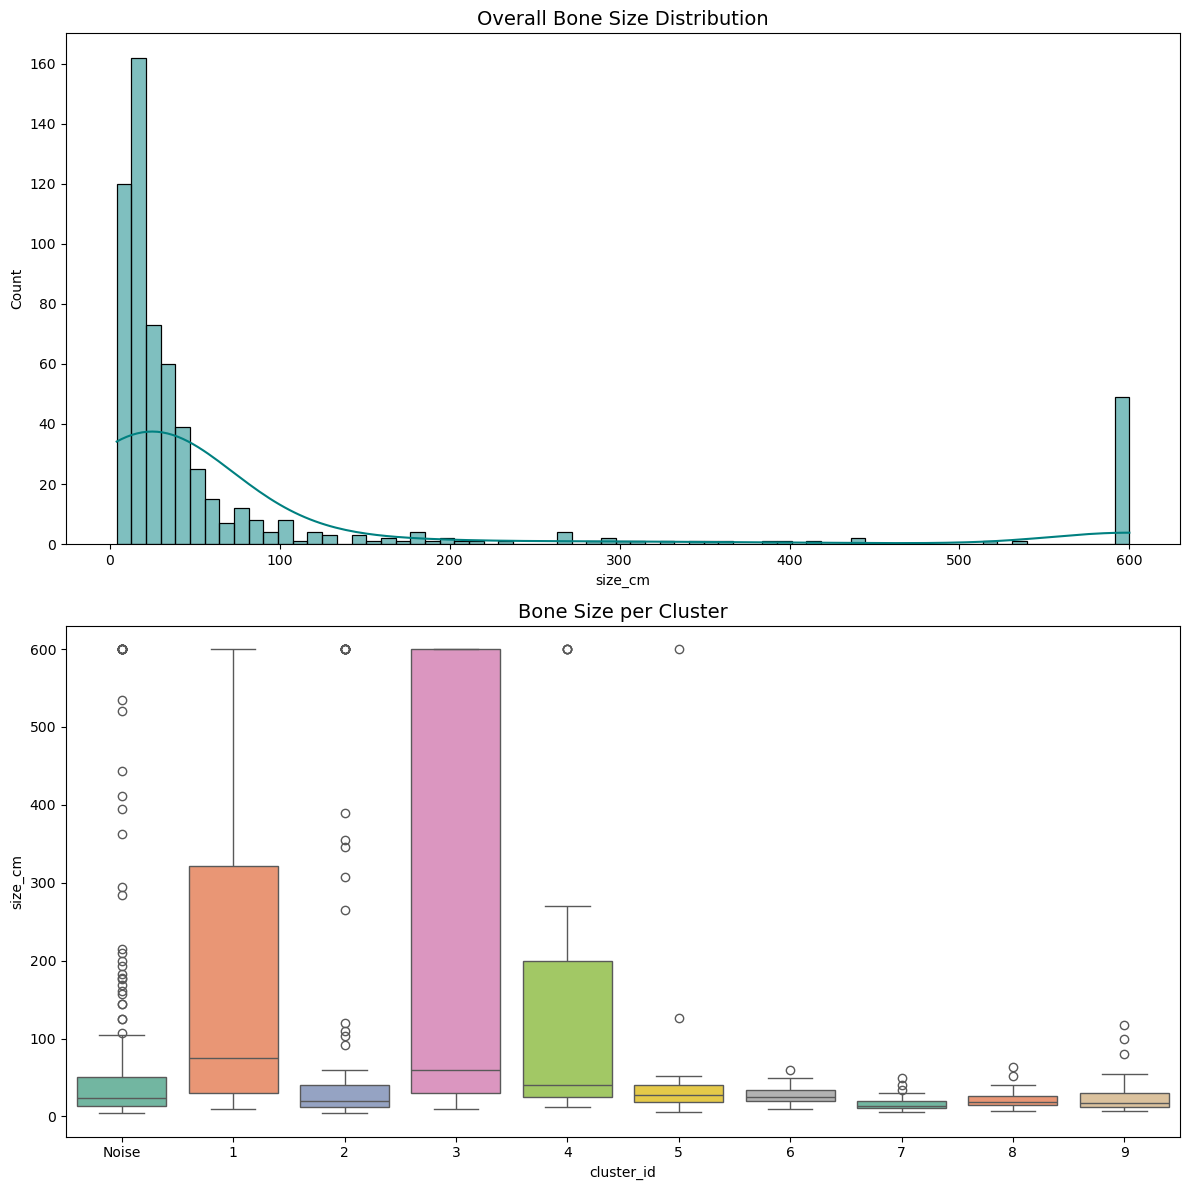

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# =================================================================
# 1. CONFIGURATION
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
input_name = 'Gashamna_Whale_Clusters_Final.gpkg'
points_path = os.path.join(base_path, input_name)
length_col = 'size_cm'

# =================================================================
# 2. DATA PREPARATION (Load Pre-clustered Data)
# =================================================================
# Load pre-clustered points from DBSCAN output
whales = gpd.read_file(points_path, layer='Points')

whales[length_col] = pd.to_numeric(whales[length_col], errors='coerce')

# Subset for statistical analysis (bones with valid length measurements)
whales_with_len = whales.dropna(subset=[length_col]).copy()
whales_with_len['cluster_id'] = whales_with_len['cluster_id'].astype(int).astype(str).replace({'-1': 'Noise'})

# =================================================================
# 3. LENGTH STATISTICS (NO WARNINGS)
# =================================================================
if not whales_with_len.empty:
    fig2, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 12))

    # Distribution histogram
    sns.histplot(data=whales_with_len, x=length_col, kde=True, ax=ax_top, color='teal')
    ax_top.set_title('Overall Bone Size Distribution', fontsize=14)
    
    # Boxplot per cluster (fixed warning by using hue)
    unique_clusters = sorted([int(x) for x in whales_with_len['cluster_id'].unique() if x != 'Noise'])
    plot_order = ['Noise'] + [str(x) for x in unique_clusters]
    sns.boxplot(data=whales_with_len, x='cluster_id', order=plot_order, y=length_col, 
                ax=ax_bot, hue='cluster_id', palette='Set2', legend=False)
    ax_bot.set_title('Bone Size per Cluster', fontsize=14)

    plt.tight_layout()
    plt.savefig(os.path.join(base_path, 'Whale_Length_Statistics_Clean.png'), dpi=300)

plt.show()